In [9]:
!pip install numpy.typing==1.1.1

  Preparing metadata (setup.py) ... done
  Created wheel for numpy.typing: filename=numpy_typing-1.1.1-py3-none-any.whl size=6564 sha256=4e9bde9f7724a8cda550d1f7755a892132676e3909dba711c77f31d9c723fc7e
  Stored in directory: /root/.cache/pip/wheels/0b/9d/a3/ae73b45a6d8bf1d0f4ef6bc897a9d11be82b1b261836c6f156
Successfully built numpy.typing

[notice] A new release of pip is available: 23.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


In [48]:

import pandas as pd 
from sklearn.model_selection import train_test_split

# y = pd.read_csv("/work/A_y_lagged_VIX.csv", index_col=0)
# X = pd.read_csv("/work/A_X_lagged_VIX.csv", index_col=0)

y = pd.read_csv("AY_DATA.csv", index_col=0, parse_dates=True)
X = pd.read_csv("AX_DATA.csv", index_col=0, parse_dates=True)

X = X.drop("DS", axis=1)
X = X.drop("DPR", axis=1)
X = X.drop("STR", axis=1)
X = X.drop("MKT", axis=1)
X = X.drop("SPX Index - Volume", axis=1)
X = X.drop("Jump", axis=1)
X = X.drop("realized_skew", axis=1)
# X = X.drop("realized_kurt", axis=1)
#X = X.drop("RV_month", axis=1)
#X = X.drop("RV_week", axis=1)
#X = X.drop("RV_day", axis=1)
#X = X.drop("VIX", axis=1)


X = X.drop("vix_term_relative", axis=1)
X = X.drop("VIX_relative_week", axis=1)
X = X.drop("VIX_relative_month", axis=1)

X = X.drop("vix_term_ratio", axis=1)
X = X.drop("VIX_ratio_week", axis=1)
X = X.drop("VIX_ratio_month", axis=1)


vix_array = X[1574:]['VIX']
rv_array = X[1574:]['RV_day']

X = X[1574:]
y = y[1574:]

#start_date = '2018-05-20'

#end_date = '2020-09-30'

#X = X.loc[start_date:end_date]
#y = y.loc[start_date:end_date]


In [10]:
len(vix_array), len(rv_array)

(1001, 1001)

In [13]:
from sklearn.preprocessing import StandardScaler

import joblib

# Load scaler later
scaler = joblib.load('/work/y_scaler_f_correct_scale.pkl')

In [10]:
len(y)


2744

In [15]:
!pip install statsmodels
import statsmodels.api as sm


[notice] A new release of pip is available: 23.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


In [5]:
!pip install xgboost==3.0.2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.9/253.9 MB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.5/322.5 MB 1.9 MB/s eta 0:00:00

[notice] A new release of pip is available: 23.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


In [16]:
import numpy as np
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.mixture import BayesianGaussianMixture
from xgboost import XGBClassifier
from scipy.stats import mood

def mood_segmentation(y, window=5, alpha=0.05):
    change_points = []
    for t in range(window, len(y) - window):
        left, right = y[t - window:t], y[t:t + window]
        stat, p = mood(left, right)
        if p < alpha:
            change_points.append(t)
    return sorted(set(change_points))

def extract_features(rv, vix, start_idx, end_idx):
    X = []
    for i in range(start_idx, end_idx):
        RV_d, RV_w, RV_m = rv[i - 1], np.mean(rv[i - 5:i]), np.mean(rv[i - 22:i])
        VIX_d, VIX_w, VIX_m = vix[i - 1], np.mean(vix[i - 5:i]), np.mean(vix[i - 22:i])
        X.append([RV_d, RV_w, RV_m, VIX_d, VIX_w, VIX_m])
    return np.array(X)

def fit_wls_model(X, y, weights):
    try:
        X_const = sm.add_constant(X, has_constant='add')
        model = sm.WLS(y, X_const, weights=weights).fit()
        return model
    except:
        return None

def rolling_recursive_dual_har_coeff_clustered(y_rv, y_vix, train_days=441, predict_days=63, mood_window=8, mood_alpha=0.05, n_clusters=3):
    y_rv = np.asarray(y_rv).flatten()
    y_vix = np.asarray(y_vix).flatten()
    n = len(y_rv)
    assert len(y_rv) == len(y_vix)

    predictions_rv, predictions_vix = [], []
    prediction_indices, true_rv = [], []

    start = 22

    while start + train_days < n:
        end_train = start + train_days
        end_test = min(end_train + predict_days, n)

        rv_full, vix_full = y_rv[:end_train], y_vix[:end_train]
        rv_train, vix_train = rv_full[start:end_train], vix_full[start:end_train]

        if np.isnan(rv_train).any() or np.isnan(vix_train).any():
            start += 1
            continue

        X_train = extract_features(rv_full, vix_full, start, end_train)

        # === Mood-based segmentation
        change_points = mood_segmentation(rv_train, window=mood_window, alpha=mood_alpha)
        change_points = [0] + change_points + [len(rv_train)]

        # === Extract segment-wise coefficients
        coeffs, segment_feats, y_segments = [], [], []
        for i in range(len(change_points) - 1):
            s, e = change_points[i], change_points[i + 1]
            # if e - s < 10: continue
            X_seg = X_train[s:e]
            y_seg = rv_train[s:e]
            try:
                model = sm.OLS(y_seg, sm.add_constant(X_seg)).fit()
                coeffs.append(model.params)
                segment_feats.append(X_seg.mean(axis=0))
                y_segments.append(y_seg)
            except:
                continue

        if len(coeffs) < 1:
            start += 1
            continue

        coeff_matrix = np.nan_to_num(np.array(coeffs))
        scaler = StandardScaler()
        coeff_scaled = scaler.fit_transform(coeff_matrix)
        pca = PCA(n_components=min(3, coeff_scaled.shape[1]))
        coeff_pca = pca.fit_transform(coeff_scaled)

        bgmm = BayesianGaussianMixture(n_components=n_clusters, random_state=42, max_iter=500)
        bgmm.fit(coeff_pca)
        cluster_probs = bgmm.predict_proba(coeff_pca)
        cluster_labels = bgmm.predict(coeff_pca)

        # === Build soft-weighted WLS models
        cluster_models = {}
        for k in range(n_clusters):
            weights = np.zeros(len(rv_train))
            for j, (s, e) in enumerate(zip(change_points[:-1], change_points[1:])):
                weights[s:e] += cluster_probs[j, k]
            model = fit_wls_model(X_train, rv_train, weights)
            if model: cluster_models[k] = model

        # === Train XGB to assign soft cluster weights
        xgb = XGBClassifier(n_estimators=300, max_depth=10, learning_rate=0.03,
                            use_label_encoder=False, eval_metric='mlogloss', random_state=42)
        xgb.fit(np.array(segment_feats), cluster_labels)

        # === Recursive Forecasting
        rv_hist = list(rv_full[end_train - 22:end_train])
        vix_hist = list(vix_full[end_train - 22:end_train])
        preds_rv, preds_vix = [], []

        for _ in range(end_test - end_train):
            X_rec = np.array([
                rv_hist[-1], np.mean(rv_hist[-5:]), np.mean(rv_hist[-22:]),
                vix_hist[-1], np.mean(vix_hist[-5:]), np.mean(vix_hist[-22:])
            ]).reshape(1, -1)

            # Soft cluster weights from XGB
            xgb_probs = xgb.predict_proba(X_rec)[0]

            # Predict VIX and RV with blended weights
            vix_pred, rv_pred = 0, 0
            X_rec_const = sm.add_constant(X_rec, has_constant='add')
            for k, model in cluster_models.items():
                # try:
                    vix_k = model.predict(X_rec_const)[0]  # same model for RV and VIX here
                    rv_k = model.predict(X_rec_const)[0]
                    vix_pred += vix_k * xgb_probs[k]
                    rv_pred += rv_k * xgb_probs[k]
                # except:
                #     print("HIHI")
                #     continue

            preds_vix.append(vix_pred)
            preds_rv.append(rv_pred)
            vix_hist.append(vix_pred); vix_hist.pop(0)
            rv_hist.append(rv_pred); rv_hist.pop(0)

        predictions_rv.append(preds_rv)
        predictions_vix.append(preds_vix)
        prediction_indices.append(np.arange(end_train, end_test))
        true_rv.append(y_rv[end_train:end_test])
        start += 1

    return (
        np.concatenate(predictions_rv),
        np.concatenate(predictions_vix),
        np.concatenate(prediction_indices),
        np.concatenate(true_rv)
    )


ModuleNotFoundError: No module named 'xgboost'

In [97]:
import numpy as np
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.mixture import BayesianGaussianMixture
from xgboost import XGBClassifier
from scipy.stats import mood

def mood_segmentation(y, window=5, alpha=0.05):
    change_points = []
    for t in range(window, len(y) - window):
        left, right = y[t - window:t], y[t:t + window]
        stat, p = mood(left, right)
        if p < alpha:
            change_points.append(t)
    return sorted(set(change_points))

def extract_features(rv, vix, start_idx, end_idx):
    X = []
    for i in range(start_idx, end_idx):
        # Defensive: ensure indices are valid for rolling windows
        if i < 22 or i < 5:
            continue
        
        RV_d = rv[i - 1]
        RV_w = np.mean(rv[i - 5:i])
        RV_m = np.mean(rv[i - 22:i])
        VIX_d = vix[i - 1]
        VIX_w = np.mean(vix[i - 5:i])
        VIX_m = np.mean(vix[i - 22:i])
        X.append([RV_d, RV_w, RV_m, VIX_d, VIX_w, VIX_m])
    return np.array(X)

def fit_wls_model(X, y, weights):
    try:
        X_const = sm.add_constant(X, has_constant='add')
        model = sm.WLS(y, X_const, weights=weights).fit()
        return model
    except Exception as e:
        # Optionally log: print(f"WLS fit failed: {e}")
        return None

def rolling_recursive_dual_har_coeff_clustered(
    y_rv, y_vix,
    train_days=441, predict_days=63,
    mood_window=8, mood_alpha=0.05,
    n_clusters=3
):
    y_rv = np.asarray(y_rv).flatten()
    y_vix = np.asarray(y_vix).flatten()
    n = len(y_rv)
    assert len(y_rv) == len(y_vix)

    predictions_rv, predictions_vix = [], []
    prediction_indices, true_rv = [], []

    start = 22  # minimal index for rolling windows

    while start + train_days < n:
        end_train = start + train_days
        end_test = min(end_train + predict_days, n)

        rv_full, vix_full = y_rv[:end_train], y_vix[:end_train]
        rv_train, vix_train = rv_full[start:end_train], vix_full[start:end_train]

        # Skip if NaNs present in training window
        if np.isnan(rv_train).any() or np.isnan(vix_train).any():
            start += 1
            continue

        X_train = extract_features(rv_full, vix_full, start, end_train)
        if len(X_train) != len(rv_train):
            # Defensive: feature extraction mismatch
            start += 1
            continue

        if np.isnan(X_train).any():
            start += 1
            continue

        # === Mood-based segmentation on RV training data
        change_points = mood_segmentation(rv_train, window=mood_window, alpha=mood_alpha)
        # Add start and end boundaries
        change_points = [0] + change_points + [len(rv_train)]

        # === Extract segment-wise coefficients, features, and targets
        coeffs, segment_feats, y_segments = [], [], []
        for i in range(len(change_points) - 1):
            s, e = change_points[i], change_points[i + 1]
            if e - s < 10:
                continue  # skip very short segments

            X_seg = X_train[s:e]
            y_seg = rv_train[s:e]

            # Defensive check: ensure X_seg has enough rows and no NaNs
            if len(X_seg) < 10 or np.isnan(X_seg).any() or np.isnan(y_seg).any():
                continue

            # Add constant column for OLS
            X_seg_const = sm.add_constant(X_seg, has_constant='add')
            # Check rank to avoid singular matrix
            if np.linalg.matrix_rank(X_seg_const) < X_seg_const.shape[1]:
                continue

            try:
                model = sm.OLS(y_seg, X_seg_const).fit()
            except Exception:
                continue

            # Confirm expected number of coefficients (1 intercept + 6 features)
            if len(model.params) != 7:
                continue

            coeffs.append(model.params)
            segment_feats.append(X_seg.mean(axis=0))
            y_segments.append(y_seg)

        # Need at least 2 segments to cluster meaningfully
        if len(coeffs) < 2:
            start += 1
            continue

        coeff_matrix = np.nan_to_num(np.array(coeffs))
        scaler = StandardScaler()
        coeff_scaled = scaler.fit_transform(coeff_matrix)
        pca = PCA(n_components=min(3, coeff_scaled.shape[1]))
        coeff_pca = pca.fit_transform(coeff_scaled)

        # Fit Bayesian Gaussian Mixture Model for soft clustering
        bgmm = BayesianGaussianMixture(
            n_components=n_clusters,
            random_state=42,
            max_iter=500
        )
        try:
            bgmm.fit(coeff_pca)
        except Exception:
            start += 1
            continue

        cluster_probs = bgmm.predict_proba(coeff_pca)
        cluster_labels = bgmm.predict(coeff_pca)

        # Check for at least 2 unique clusters in the data
        if len(np.unique(cluster_labels)) < 2:
            start += 1
            continue

        # === Build soft-weighted WLS models per cluster
        cluster_models = {}
        for k in range(n_clusters):
            weights = np.zeros(len(rv_train))
            # Defensive: don't exceed cluster_probs length
            limit = min(len(change_points) - 1, cluster_probs.shape[0])
            for j, (s, e) in enumerate(zip(change_points[:-1], change_points[1:])):
                if j >= limit:
                    break
                weights[s:e] += cluster_probs[j, k]

            # Skip clusters with zero weights
            if np.sum(weights) == 0:
                continue

            model = fit_wls_model(X_train, rv_train, weights)
            if model is not None:
                cluster_models[k] = model

        # Need at least one cluster model for forecasting
        if len(cluster_models) == 0:
            start += 1
            continue

        # === Train XGB classifier to predict soft cluster weights from segment features
        segment_feats_arr = np.array(segment_feats)
        cluster_labels_arr = np.array(cluster_labels)

        # Defensive: skip if XGB labels are degenerate
        if len(np.unique(cluster_labels_arr)) < 2:
            start += 1
            continue

        xgb = XGBClassifier(
            n_estimators=300,
            max_depth=10,
            learning_rate=0.03,
            use_label_encoder=False,
            eval_metric='mlogloss',
            random_state=42
        )
        try:
            xgb.fit(segment_feats_arr, cluster_labels_arr)
        except Exception:
            start += 1
            continue

        # === Recursive forecasting for predict_days ahead
        rv_hist = list(rv_full[end_train - 22:end_train])
        vix_hist = list(vix_full[end_train - 22:end_train])
        preds_rv, preds_vix = [], []

        for _ in range(end_test - end_train):
            X_rec = np.array([
                rv_hist[-1], np.mean(rv_hist[-5:]), np.mean(rv_hist[-22:]),
                vix_hist[-1], np.mean(vix_hist[-5:]), np.mean(vix_hist[-22:])
            ]).reshape(1, -1)

            # Predict cluster membership probabilities with XGB
            try:
                xgb_probs = xgb.predict_proba(X_rec)[0]
            except Exception:
                break

            vix_pred, rv_pred = 0.0, 0.0
            X_rec_const = sm.add_constant(X_rec, has_constant='add')

            # Weighted prediction across cluster models
            for k, model in cluster_models.items():
                try:
                    pred = model.predict(X_rec_const)[0]
                    vix_pred += pred * xgb_probs[k]
                    rv_pred += pred * xgb_probs[k]
                except Exception:
                    continue

            preds_vix.append(vix_pred)
            preds_rv.append(rv_pred)

            # Update history windows for next prediction
            vix_hist.append(vix_pred)
            vix_hist.pop(0)
            rv_hist.append(rv_pred)
            rv_hist.pop(0)

        # Append results of this iteration
        if len(preds_rv) > 0:
            predictions_rv.append(np.array(preds_rv))
            predictions_vix.append(np.array(preds_vix))
            prediction_indices.append(np.arange(end_train, end_test))
            true_rv.append(y_rv[end_train:end_test])

        start += 1

    # Defensive: handle empty predictions gracefully
    if len(predictions_rv) == 0:
        return np.array([]), np.array([]), np.array([]), np.array([])

    return (
        np.concatenate(predictions_rv),
        np.concatenate(predictions_vix),
        np.concatenate(prediction_indices),
        np.concatenate(true_rv)
    )


In [24]:
!pip install xgboost==3.0.2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.9/253.9 MB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.5/322.5 MB 2.1 MB/s eta 0:00:00

[notice] A new release of pip is available: 23.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


In [12]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.mixture import BayesianGaussianMixture
from xgboost import XGBClassifier
from scipy.stats import mood

def mood_segmentation(y, window=5, alpha=0.05):
    change_points = []
    for t in range(window, len(y) - window):
        left = y[t - window:t]
        right = y[t:t + window]
        stat, p = mood(left, right)
        if p < alpha:
            change_points.append(t)
    return sorted(set(change_points))

def calculate_linear_regression_coefficients(X, y, features):
    try:
        X_const = sm.add_constant(X[features], has_constant='add')
        model = sm.OLS(y, X_const).fit()
        return model.params.values, model, True
    except:
        from sklearn.linear_model import Ridge
        try:
            ridge = Ridge(alpha=1e-3)
            ridge.fit(X[features], y)
            coefficients = np.concatenate([[ridge.intercept_], ridge.coef_])
            return coefficients, ridge, False
        except:
            return np.zeros(len(features) + 1), None, False

def cluster_coefficients_soft_bayesian_gmm(coeff_matrix, n_components=5, apply_pca=True, n_pca=3):
    scaler = StandardScaler()
    coeff_scaled = scaler.fit_transform(np.nan_to_num(coeff_matrix))

    if apply_pca and coeff_scaled.shape[1] > n_pca:
        pca = PCA(n_components=n_pca)
        coeff_scaled = pca.fit_transform(coeff_scaled)
    else:
        pca = None

    bgmm = BayesianGaussianMixture(n_components=n_components, covariance_type='full', random_state=42, max_iter=500)
    bgmm.fit(coeff_scaled)

    cluster_probs = bgmm.predict_proba(coeff_scaled)
    cluster_labels = bgmm.predict(coeff_scaled)
    return cluster_probs, cluster_labels, bgmm, scaler, pca

def build_har_features(rv_hist, vix_hist):
    # Assumes rv_hist and vix_hist are lists/arrays with length >= 22
    RV_d = rv_hist[-1]
    RV_w = np.mean(rv_hist[-5:])
    RV_m = np.mean(rv_hist[-22:])
    VIX_d = vix_hist[-1]
    VIX_w = np.mean(vix_hist[-5:])
    VIX_m = np.mean(vix_hist[-22:])
    return [RV_d, RV_w, RV_m, VIX_d, VIX_w, VIX_m]

def rolling_recursive_dual_har_coeff_clustered(y_rv, y_vix, train_days=441, predict_days=5, n_clusters=3,
                                               mood_window=8, mood_alpha=0.05, features=None):
    # y_rv, y_vix: arrays or series of RV and VIX
    # features: list of feature column names in constructed DataFrame (optional, will build below if None)
    y_rv = np.asarray(y_rv).flatten()
    y_vix = np.asarray(y_vix).flatten()
    n = len(y_rv)
    assert len(y_rv) == len(y_vix), "RV and VIX must be same length."

    # Pre-construct the DataFrame of features per day in training window for clustering pipeline
    # We'll use the same HAR + VIX features as in your initial function
    def construct_full_feature_df(rv_array, vix_array):
        rows = []
        for i in range(22, len(rv_array)):
            feats = build_har_features(rv_array[i-22:i], vix_array[i-22:i])
            rows.append(feats)
        df = pd.DataFrame(rows, columns=[
            'RV_d', 'RV_w', 'RV_m', 'VIX_d', 'VIX_w', 'VIX_m'
        ])
        return df

    # If no explicit feature names provided, set default HAR features
    if features is None:
        features = ['RV_d', 'RV_w', 'RV_m', 'VIX_d', 'VIX_w', 'VIX_m']

    predictions_rv = []
    predictions_vix = []
    prediction_indices = []
    true_rv = []

    start = 22  # Because we need 22 days lag for features

    while start + train_days < n:
        end_train = start + train_days
        end_test = min(end_train + predict_days, n)

        # Full training arrays for RV and VIX (for features and lag history)
        rv_train_full = y_rv[:end_train]
        vix_train_full = y_vix[:end_train]

        # Build features DataFrame for training period (starting at index 22)
        X_train = construct_full_feature_df(rv_train_full, vix_train_full)
        y_train_rv = rv_train_full[22:]  # Align target to feature index (same length as X_train)
        y_train_vix = vix_train_full[22:]

        # Mood segmentation and coefficient extraction on RV and VIX separately
        # We'll cluster using RV coefficients only for simplicity, but you can do VIX similarly
        change_points = mood_segmentation(y_train_rv, window=mood_window, alpha=mood_alpha)
        if not change_points:
            change_points = [len(y_train_rv) // 2]
        change_points = sorted([0] + change_points + [len(y_train_rv)])

        segment_coeffs = []
        segment_info = []
        for i in range(len(change_points) - 1):
            s, e = change_points[i], change_points[i + 1]
            if e - s < len(features) + 2:
                continue
            X_seg = X_train.iloc[s:e]
            y_seg = y_train_rv[s:e]
            coeff, model, is_ols = calculate_linear_regression_coefficients(X_seg, y_seg, features)
            segment_coeffs.append(coeff)
            segment_info.append({'start': s, 'end': e, 'model': model})

        # If no segments extracted (too short), fit one on whole training
        if not segment_coeffs:
            coeff, model, _ = calculate_linear_regression_coefficients(X_train, y_train_rv, features)
            segment_coeffs = [coeff]
            segment_info = [{'start': 0, 'end': len(y_train_rv), 'model': model}]

        coeff_matrix = np.array(segment_coeffs)

        # Cluster coefficients with Bayesian Gaussian Mixture
        cluster_probs, cluster_labels, bgmm, coeff_scaler, coeff_pca = cluster_coefficients_soft_bayesian_gmm(
            coeff_matrix, n_components=n_clusters)

        # Remap cluster labels to 0-based consecutive integers
        unique_labels = np.unique(cluster_labels)
        label_map = {old_label: new_label for new_label, old_label in enumerate(unique_labels)}
        cluster_labels_mapped = np.array([label_map[label] for label in cluster_labels])
        sorted_labels = np.sort(unique_labels)
        cluster_probs_mapped = cluster_probs[:, np.argsort(sorted_labels)]
        n_actual_clusters = len(unique_labels)

        # Build point-wise soft cluster weights matrix for each training day (for WLS)
        weights_matrix = np.zeros((len(y_train_rv), n_actual_clusters))
        for i, seg in enumerate(segment_info):
            for k in range(n_actual_clusters):
                weights_matrix[seg['start']:seg['end'], k] = cluster_probs_mapped[i, k]

        # Fit per-cluster WLS models on training data using soft weights
        cluster_models = {}
        X_train_const = sm.add_constant(X_train[features], has_constant='add')
        for k in range(n_actual_clusters):
            weights = weights_matrix[:, k]
            if np.sum(weights) < len(features) + 1:
                continue
            try:
                model = sm.WLS(y_train_rv, X_train_const, weights=weights).fit()
                cluster_models[k] = model
            except Exception as e:
                print(f"Cluster {k} model fit failed: {e}")

        # Train XGBoost classifier to predict cluster from segment means
        segment_features = []
        for seg in segment_info:
            X_seg = X_train.iloc[seg['start']:seg['end']]
            mean_feats = X_seg[features].mean().values
            segment_features.append(mean_feats)
        segment_features = np.array(segment_features)

        cluster_classifier = XGBClassifier(
            n_estimators=400,
            max_depth=10,
            learning_rate=0.05,
            use_label_encoder=False,
            eval_metric='mlogloss',
            random_state=24,
            base_score=0.5
        )
        cluster_classifier.fit(segment_features, cluster_labels_mapped)

        # Initialize lag histories for recursive forecast
        rv_hist = list(rv_train_full[end_train - 22:end_train])
        vix_hist = list(vix_train_full[end_train - 22:end_train])

        preds_rv = []
        preds_vix = []

        actual_predict_days = end_test - end_train

        for step in range(actual_predict_days):
            # Build feature vector from lag histories
            feats = build_har_features(rv_hist, vix_hist)
            X_current = pd.DataFrame([feats], columns=features)

            # Predict cluster probabilities for current day using XGB classifier
            cluster_prob_pred = cluster_classifier.predict_proba(X_current)[0]

            # Predict VIX recursively using same cluster models concept:
            # Here, for simplicity, fit cluster models for VIX the same way, or fallback to OLS from RV
            # (You could duplicate the clustering for VIX for more accuracy)

            # For demo: predict VIX by weighted average of RV cluster models on VIX features (rough approximation)
            # Build feature const for VIX prediction
            X_current_const = sm.add_constant(X_current, has_constant='add')
            pred_vix_k = []
            for k in range(n_actual_clusters):
                model = cluster_models.get(k)
                if model is not None:
                    pred_vix_k.append(model.predict(X_current_const)[0])
                else:
                    pred_vix_k.append(0.0)
            next_vix = np.sum(np.array(pred_vix_k) * cluster_prob_pred)

            # Append and update vix history
            vix_hist.append(next_vix)
            vix_hist.pop(0)

            # Predict RV using updated VIX in features
            feats = build_har_features(rv_hist, vix_hist)
            X_current = pd.DataFrame([feats], columns=features)
            X_current_const = sm.add_constant(X_current, has_constant='add')

            pred_rv_k = []
            for k in range(n_actual_clusters):
                model = cluster_models.get(k)
                if model is not None:
                    pred_rv_k.append(model.predict(X_current_const)[0])
                else:
                    pred_rv_k.append(0.0)
            next_rv = np.sum(np.array(pred_rv_k) * cluster_prob_pred)

            # Append and update rv history
            rv_hist.append(next_rv)
            rv_hist.pop(0)

            preds_rv.append(next_rv)
            preds_vix.append(next_vix)

        idx = np.arange(end_train, end_test)
        true = y_rv[end_train:end_test]

        predictions_rv.append(preds_rv)
        predictions_vix.append(preds_vix)
        prediction_indices.append(idx)
        true_rv.append(true)

        start += 1  # Move window forward by one day for next training

    return (
        np.concatenate(predictions_rv),
        np.concatenate(predictions_vix),
        np.concatenate(prediction_indices),
        np.concatenate(true_rv)
    )


In [40]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.mixture import BayesianGaussianMixture
from xgboost import XGBClassifier
from scipy.stats import mood


def mood_segmentation(y, window=5, alpha=0.05):
    change_points = []
    for t in range(window, len(y) - window):
        left = y[t - window:t]
        right = y[t:t + window]
        stat, p = mood(left, right)
        if p < alpha:
            change_points.append(t)
    return sorted(set(change_points))


def calculate_linear_regression_coefficients(X, y, features):
    try:
        X_const = sm.add_constant(X[features], has_constant='add')
        model = sm.OLS(y, X_const).fit()
        return model.params.values, model, True
    except:
        from sklearn.linear_model import Ridge
        try:
            ridge = Ridge(alpha=1e-3)
            ridge.fit(X[features], y)
            coefficients = np.concatenate([[ridge.intercept_], ridge.coef_])
            return coefficients, ridge, False
        except:
            return np.zeros(len(features) + 1), None, False


def cluster_coefficients_soft_bayesian_gmm(coeff_matrix, n_components=5, apply_pca=True, n_pca=3):
    scaler = StandardScaler()
    coeff_scaled = scaler.fit_transform(np.nan_to_num(coeff_matrix))

    if apply_pca and coeff_scaled.shape[1] > n_pca:
        pca = PCA(n_components=n_pca)
        coeff_scaled = pca.fit_transform(coeff_scaled)
    else:
        pca = None

    bgmm = BayesianGaussianMixture(n_components=n_components, covariance_type='full', random_state=42, max_iter=500)
    bgmm.fit(coeff_scaled)

    cluster_probs = bgmm.predict_proba(coeff_scaled)
    cluster_labels = bgmm.predict(coeff_scaled)
    return cluster_probs, cluster_labels, bgmm, scaler, pca


def build_har_features(rv_hist, vix_hist):
    RV_d = rv_hist[-1]
    RV_w = np.mean(rv_hist[-5:])
    RV_m = np.mean(rv_hist[-22:])
    VIX_d = vix_hist[-1]
    VIX_w = np.mean(vix_hist[-5:])
    VIX_m = np.mean(vix_hist[-22:])
    return [RV_d, RV_w, RV_m, VIX_d, VIX_w, VIX_m]


def rolling_recursive_dual_har_coeff_clustered_strict(
    y_rv, y_vix, train_days=441, predict_days=5,
    n_clusters=3, mood_window=8, mood_alpha=0.05, features=None):

    y_rv = np.asarray(y_rv).flatten()
    y_vix = np.asarray(y_vix).flatten()
    n = len(y_rv)
    assert len(y_rv) == len(y_vix), "RV and VIX series must be same length."

    if features is None:
        features = ['RV_d', 'RV_w', 'RV_m', 'VIX_d', 'VIX_w', 'VIX_m']

    def construct_features_df(rv_array, vix_array):
        rows = []
        for i in range(22, len(rv_array)):
            feats = build_har_features(rv_array[i-22:i], vix_array[i-22:i])
            rows.append(feats)
        return pd.DataFrame(rows, columns=features)

    predictions_rv, predictions_vix, prediction_indices, true_rv = [], [], [], []
    cluster_preds_rv, cluster_preds_vix = [], []

    start = 22
    while start + train_days < n:
        end_train = start + train_days
        end_test = min(end_train + predict_days, n)

        rv_train_full = y_rv[:end_train]
        vix_train_full = y_vix[:end_train]

        X_train = construct_features_df(rv_train_full, vix_train_full)
        y_train_rv = rv_train_full[22:]
        y_train_vix = vix_train_full[22:]

        def build_cluster_model(X_train, y_train):
            change_points = mood_segmentation(y_train, mood_window, mood_alpha)
            if not change_points:
                change_points = [len(y_train) // 2]
            change_points = sorted([0] + change_points + [len(y_train)])

            segment_coeffs, segment_info = [], []
            for i in range(len(change_points) - 1):
                s, e = change_points[i], change_points[i + 1]
                if e - s < len(features) + 2:
                    continue
                coeff, model, _ = calculate_linear_regression_coefficients(X_train.iloc[s:e], y_train[s:e], features)
                segment_coeffs.append(coeff)
                segment_info.append({'start': s, 'end': e, 'model': model})

            if not segment_coeffs:
                coeff, model, _ = calculate_linear_regression_coefficients(X_train, y_train, features)
                segment_coeffs = [coeff]
                segment_info = [{'start': 0, 'end': len(y_train), 'model': model}]

            coeff_matrix = np.array(segment_coeffs)
            cluster_probs, cluster_labels, bgmm, coeff_scaler, coeff_pca = cluster_coefficients_soft_bayesian_gmm(coeff_matrix, n_clusters)
            label_map = {old: new for new, old in enumerate(np.unique(cluster_labels))}
            cluster_labels = np.array([label_map[l] for l in cluster_labels])
            cluster_probs = cluster_probs[:, np.argsort(list(label_map.keys()))]
            K = cluster_probs.shape[1]
            weights_matrix = np.zeros((len(y_train), K))
            for i, seg in enumerate(segment_info):
                for k in range(K):
                    weights_matrix[seg['start']:seg['end'], k] = cluster_probs[i, k]

            models = {}
            for k in range(K):
                weights = weights_matrix[:, k]
                try:
                    X_const = sm.add_constant(X_train[features], has_constant='add')
                    model = sm.WLS(y_train, X_const, weights=weights).fit()
                    models[k] = model
                except:
                    continue

            X_daily = X_train[features].values
            y_daily = np.argmax(weights_matrix, axis=1)
            clf = XGBClassifier(n_estimators=400, max_depth=10, learning_rate=0.05,
                                use_label_encoder=False, eval_metric='mlogloss', random_state=42)
            clf.fit(X_daily, y_daily)
            return models, clf, K

        model_rv, clf_rv, K_rv = build_cluster_model(X_train, y_train_rv)
        model_vix, clf_vix, K_vix = build_cluster_model(X_train, y_train_vix)

        rv_hist = list(rv_train_full[end_train - 22:end_train])
        vix_hist = list(vix_train_full[end_train - 22:end_train])

        preds_rv, preds_vix = [], []
        cluster_labels_rv, cluster_labels_vix = [], []

        for step in range(end_test - end_train):
            feats = build_har_features(rv_hist, vix_hist)
            X_step = pd.DataFrame([feats], columns=features)
            X_step_const = sm.add_constant(X_step, has_constant='add')

            p_vix = clf_vix.predict_proba(X_step.values)[0]
            pred_vix = sum(model_vix[k].predict(X_step_const)[0] * p_vix[k] for k in range(K_vix) if k in model_vix)

            vix_hist.append(pred_vix)
            vix_hist.pop(0)

            feats = build_har_features(rv_hist, vix_hist)
            X_step = pd.DataFrame([feats], columns=features)
            X_step_const = sm.add_constant(X_step, has_constant='add')
            p_rv = clf_rv.predict_proba(X_step.values)[0]
            pred_rv = sum(model_rv[k].predict(X_step_const)[0] * p_rv[k] for k in range(K_rv) if k in model_rv)

            rv_hist.append(pred_rv)
            rv_hist.pop(0)

            preds_rv.append(pred_rv)
            preds_vix.append(pred_vix)
            cluster_labels_rv.append(np.argmax(p_rv))
            cluster_labels_vix.append(np.argmax(p_vix))

        idx = np.arange(end_train, end_test)
        true = y_rv[end_train:end_test]

        predictions_rv.append(preds_rv)
        predictions_vix.append(preds_vix)
        prediction_indices.append(idx)
        true_rv.append(true)
        cluster_preds_rv.append(cluster_labels_rv)
        cluster_preds_vix.append(cluster_labels_vix)

        start += 1

    return (
        np.concatenate(predictions_rv),
        np.concatenate(predictions_vix),
        np.concatenate(prediction_indices),
        np.concatenate(true_rv),
        np.concatenate(cluster_preds_rv),
        np.concatenate(cluster_preds_vix)
    )


In [49]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.mixture import BayesianGaussianMixture
from xgboost import XGBClassifier
from scipy.stats import mood


def mood_segmentation(y, window=5, alpha=0.05):
    change_points = []
    for t in range(window, len(y) - window):
        left, right = y[t - window:t], y[t:t + window]
        stat, p = mood(left, right)
        if p < alpha:
            change_points.append(t)
    return sorted(set(change_points))


def calculate_linear_regression_coefficients(X, y, features):
    try:
        X_const = sm.add_constant(X[features], has_constant='add')
        model = sm.OLS(y, X_const).fit()
        return model.params.values, model, True
    except:
        return np.zeros(len(features) + 1), None, False


def cluster_coefficients_soft_bayesian_gmm(coeff_matrix, n_components=5, apply_pca=True, n_pca=3):
    scaler = StandardScaler()
    coeff_scaled = scaler.fit_transform(np.nan_to_num(coeff_matrix))

    if apply_pca and coeff_scaled.shape[1] > n_pca:
        pca = PCA(n_components=n_pca)
        coeff_scaled = pca.fit_transform(coeff_scaled)
    else:
        pca = None

    bgmm = BayesianGaussianMixture(n_components=n_components, covariance_type='full', random_state=42, max_iter=500)
    bgmm.fit(coeff_scaled)

    cluster_probs = bgmm.predict_proba(coeff_scaled)
    cluster_labels = bgmm.predict(coeff_scaled)
    return cluster_probs, cluster_labels, bgmm, scaler, pca


def build_har_features(rv_hist, vix_hist):
    return [
        rv_hist[-1], np.mean(rv_hist[-5:]), np.mean(rv_hist[-22:]),
        vix_hist[-1], np.mean(vix_hist[-5:]), np.mean(vix_hist[-22:])
    ]


def dual_recursive_har_soft_clustered(rv, vix, train_days=441, predict_days=5, n_clusters=3, mood_window=8, mood_alpha=0.05):
    rv, vix = np.asarray(rv).flatten(), np.asarray(vix).flatten()
    n = len(rv)
    features = ['RV_d', 'RV_w', 'RV_m', 'VIX_d', 'VIX_w', 'VIX_m']

    pred_rv, pred_vix, pred_idx, true_rv = [], [], [], []
    start = 22

    while start + train_days < n:
        end_train, end_test = start + train_days, min(start + train_days + predict_days, n)

        def train_pipeline(y_target, rv_train_full, vix_train_full):
            rows = [build_har_features(rv_train_full[i-22:i], vix_train_full[i-22:i]) for i in range(22, len(rv_train_full))]
            X = pd.DataFrame(rows, columns=features)
            y = y_target[22:]
            scaler = StandardScaler()
            X[features] = scaler.fit_transform(X[features])

            change_points = mood_segmentation(y, window=mood_window, alpha=mood_alpha)
            if not change_points:
                change_points = [len(y) // 2]
            change_points = [0] + change_points + [len(y)]

            segment_coeffs, segment_info = [], []
            for i in range(len(change_points) - 1):
                s, e = change_points[i], change_points[i + 1]
                if e - s < len(features) + 2: continue
                coeff, model, _ = calculate_linear_regression_coefficients(X.iloc[s:e], y[s:e], features)
                segment_coeffs.append(coeff)
                segment_info.append({'start': s, 'end': e, 'model': model})

            if not segment_coeffs:
                coeff, model, _ = calculate_linear_regression_coefficients(X, y, features)
                segment_coeffs = [coeff]
                segment_info = [{'start': 0, 'end': len(y), 'model': model}]

            coeff_matrix = np.array(segment_coeffs)
            cluster_probs, cluster_labels, _, _, _ = cluster_coefficients_soft_bayesian_gmm(coeff_matrix, n_components=n_clusters)

            unique_labels = np.unique(cluster_labels)
            label_map = {old: new for new, old in enumerate(sorted(unique_labels))}
            cluster_labels = np.array([label_map[l] for l in cluster_labels])
            cluster_probs = cluster_probs[:, np.argsort(unique_labels)]

            weights_matrix = np.zeros((len(y), len(unique_labels)))
            for i, seg in enumerate(segment_info):
                for k in range(len(unique_labels)):
                    weights_matrix[seg['start']:seg['end'], k] = cluster_probs[i, k]

            cluster_models = {}
            X_const = sm.add_constant(X[features], has_constant='add')
            for k in range(len(unique_labels)):
                weights = weights_matrix[:, k]
                if np.sum(weights) < len(features): continue
                model = sm.WLS(y, X_const, weights=weights).fit()
                cluster_models[k] = model

            segment_features = np.array([X.iloc[s['start']:s['end']][features].mean().values for s in segment_info])
            clf = XGBClassifier(n_estimators=400, max_depth=10, learning_rate=0.05, use_label_encoder=False, eval_metric='mlogloss')
            clf.fit(segment_features, cluster_labels)
            return cluster_models, clf, scaler

        rv_train_full, vix_train_full = rv[:end_train], vix[:end_train]
        rv_models, rv_clf, rv_scaler = train_pipeline(rv_train_full, rv_train_full, vix_train_full)
        vix_models, vix_clf, vix_scaler = train_pipeline(vix_train_full, rv_train_full, vix_train_full)

        rv_hist = list(rv_train_full[-22:])
        vix_hist = list(vix_train_full[-22:])
        preds_rv, preds_vix = [], []

        for step in range(end_test - end_train):
            feats = build_har_features(rv_hist, vix_hist)
            X_df = pd.DataFrame([feats], columns=features)
            X_scaled_rv = rv_scaler.transform(X_df[features])
            X_scaled_vix = vix_scaler.transform(X_df[features])
            X_df_rv = pd.DataFrame(X_scaled_rv, columns=features)
            X_df_vix = pd.DataFrame(X_scaled_vix, columns=features)
            X_const_rv = sm.add_constant(X_df_rv, has_constant='add')
            X_const_vix = sm.add_constant(X_df_vix, has_constant='add')

            prob_rv = rv_clf.predict_proba(X_scaled_rv)[0]
            prob_vix = vix_clf.predict_proba(X_scaled_vix)[0]

            pred_rv_step = np.sum([prob_rv[k] * rv_models[k].predict(X_const_rv)[0] for k in rv_models])
            rv_hist.append(pred_rv_step)
            rv_hist.pop(0)

            feats_vix = build_har_features(rv_hist, vix_hist)
            X_df_vix2 = pd.DataFrame([feats_vix], columns=features)
            X_scaled_vix2 = vix_scaler.transform(X_df_vix2[features])
            X_const_vix2 = sm.add_constant(X_scaled_vix2, has_constant='add')

            pred_vix_step = np.sum([prob_vix[k] * vix_models[k].predict(X_const_vix2)[0] for k in vix_models])
            vix_hist.append(pred_vix_step)
            vix_hist.pop(0)

            preds_rv.append(pred_rv_step)
            preds_vix.append(pred_vix_step)

        pred_rv.append(preds_rv)
        pred_vix.append(preds_vix)
        pred_idx.append(np.arange(end_train, end_test))
        true_rv.append(rv[end_train:end_test])

        start += 1

    return (
        np.concatenate(pred_rv),
        np.concatenate(pred_vix),
        np.concatenate(pred_idx),
        np.concatenate(true_rv)
    )


In [27]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.mixture import BayesianGaussianMixture
from xgboost import XGBClassifier
from scipy.stats import mood


def mood_segmentation(y, window=5, alpha=0.05):
    change_points = []
    for t in range(window, len(y) - window):
        left, right = y[t - window:t], y[t:t + window]
        stat, p = mood(left, right)
        if p < alpha:
            change_points.append(t)
    return sorted(set(change_points))


def calculate_linear_regression_coefficients(X, y, features):
    try:
        X_const = sm.add_constant(X[features], has_constant='add')
        model = sm.OLS(y, X_const).fit()
        return model.params.values, model, True
    except:
        from sklearn.linear_model import Ridge
        try:
            ridge = Ridge(alpha=1e-3)
            ridge.fit(X[features], y)
            coefficients = np.concatenate([[ridge.intercept_], ridge.coef_])
            return coefficients, ridge, False
        except:
            return np.zeros(len(features) + 1), None, False


def cluster_coefficients_soft_bayesian_gmm(coeff_matrix, n_components=5, apply_pca=True, n_pca=3):
    scaler = StandardScaler()
    coeff_scaled = scaler.fit_transform(np.nan_to_num(coeff_matrix))

    if apply_pca and coeff_scaled.shape[1] > n_pca:
        pca = PCA(n_components=n_pca)
        coeff_scaled = pca.fit_transform(coeff_scaled)
    else:
        pca = None

    bgmm = BayesianGaussianMixture(n_components=n_components, covariance_type='full', random_state=42, max_iter=500)
    bgmm.fit(coeff_scaled)

    cluster_probs = bgmm.predict_proba(coeff_scaled)
    cluster_labels = bgmm.predict(coeff_scaled)
    return cluster_probs, cluster_labels, bgmm, scaler, pca


def build_har_features(rv_hist, vix_hist):
    return [
        rv_hist[-1], np.mean(rv_hist[-5:]), np.mean(rv_hist[-22:]),
        vix_hist[-1], np.mean(vix_hist[-5:]), np.mean(vix_hist[-22:])
    ]


def rolling_recursive_dual_har_coeff_clustered_strict_zscored(
    y_rv, y_vix, train_days=441, predict_days=5,
    n_clusters=3, mood_window=8, mood_alpha=0.05, features=None):

    y_rv = np.asarray(y_rv).flatten()
    y_vix = np.asarray(y_vix).flatten()
    n = len(y_rv)
    assert len(y_rv) == len(y_vix), "RV and VIX series must be same length."

    if features is None:
        features = ['RV_d', 'RV_w', 'RV_m', 'VIX_d', 'VIX_w', 'VIX_m']

    def construct_features_df(rv_array, vix_array):
        rows = []
        for i in range(22, len(rv_array)):
            feats = build_har_features(rv_array[i-22:i], vix_array[i-22:i])
            rows.append(feats)
        return pd.DataFrame(rows, columns=features)

    predictions_rv, predictions_vix, prediction_indices, true_rv = [], [], [], []
    cluster_preds_rv, cluster_preds_vix = [], []

    start = 22
    while start + train_days < n:
        end_train = start + train_days
        end_test = min(end_train + predict_days, n)

        rv_train_full = y_rv[:end_train]
        vix_train_full = y_vix[:end_train]

        X_train = construct_features_df(rv_train_full, vix_train_full)
        y_train_rv = rv_train_full[22:]
        y_train_vix = vix_train_full[22:]

        def build_cluster_model(X_train, y_train):
            scaler = StandardScaler()
            X_scaled = X_train.copy()
            X_scaled[features] = scaler.fit_transform(X_scaled[features])

            change_points = mood_segmentation(y_train, mood_window, mood_alpha)
            if not change_points:
                change_points = [len(y_train) // 2]
            change_points = sorted([0] + change_points + [len(y_train)])

            segment_coeffs, segment_info = [], []
            for i in range(len(change_points) - 1):
                s, e = change_points[i], change_points[i + 1]
                if e - s < len(features) + 2:
                    continue
                coeff, model, _ = calculate_linear_regression_coefficients(X_scaled.iloc[s:e], y_train[s:e], features)
                segment_coeffs.append(coeff)
                segment_info.append({'start': s, 'end': e, 'model': model})

            if not segment_coeffs:
                coeff, model, _ = calculate_linear_regression_coefficients(X_scaled, y_train, features)
                segment_coeffs = [coeff]
                segment_info = [{'start': 0, 'end': len(y_train), 'model': model}]

            coeff_matrix = np.array(segment_coeffs)
            cluster_probs, cluster_labels, bgmm, coeff_scaler, coeff_pca = cluster_coefficients_soft_bayesian_gmm(coeff_matrix, n_clusters)

            label_map = {old: new for new, old in enumerate(np.unique(cluster_labels))}
            cluster_labels = np.array([label_map[l] for l in cluster_labels])
            cluster_probs = cluster_probs[:, np.argsort(list(label_map.keys()))]
            K = cluster_probs.shape[1]

            weights_matrix = np.zeros((len(y_train), K))
            for i, seg in enumerate(segment_info):
                for k in range(K):
                    weights_matrix[seg['start']:seg['end'], k] = cluster_probs[i, k]

            models = {}
            for k in range(K):
                weights = weights_matrix[:, k]
                try:
                    X_const = sm.add_constant(X_scaled[features], has_constant='add')
                    model = sm.WLS(y_train, X_const, weights=weights).fit()
                    models[k] = model
                except:
                    continue

            X_daily = X_scaled[features].values
            y_daily = np.argmax(weights_matrix, axis=1)
            clf = XGBClassifier(n_estimators=400, max_depth=10, learning_rate=0.05,
                                use_label_encoder=False, eval_metric='mlogloss', random_state=42)
            clf.fit(X_daily, y_daily)
            return models, clf, scaler, K

        model_rv, clf_rv, scaler_rv, K_rv = build_cluster_model(X_train, y_train_rv)
        model_vix, clf_vix, scaler_vix, K_vix = build_cluster_model(X_train, y_train_vix)

        rv_hist = list(rv_train_full[end_train - 22:end_train])
        vix_hist = list(vix_train_full[end_train - 22:end_train])

        preds_rv, preds_vix = [], []
        cluster_labels_rv, cluster_labels_vix = [], []

        for step in range(end_test - end_train):
            feats = build_har_features(rv_hist, vix_hist)
            X_step = pd.DataFrame([feats], columns=features)

            X_scaled_vix = scaler_vix.transform(X_step)
            X_const_vix = sm.add_constant(X_scaled_vix, has_constant='add')
            p_vix = clf_vix.predict_proba(X_scaled_vix)[0]
            pred_vix = sum(model_vix[k].predict(X_const_vix)[0] * p_vix[k] for k in range(K_vix) if k in model_vix)
            vix_hist.append(pred_vix)
            vix_hist.pop(0)

            feats = build_har_features(rv_hist, vix_hist)
            X_step = pd.DataFrame([feats], columns=features)
            X_scaled_rv = scaler_rv.transform(X_step)
            X_const_rv = sm.add_constant(X_scaled_rv, has_constant='add')
            p_rv = clf_rv.predict_proba(X_scaled_rv)[0]
            pred_rv = sum(model_rv[k].predict(X_const_rv)[0] * p_rv[k] for k in range(K_rv) if k in model_rv)
            rv_hist.append(pred_rv)
            rv_hist.pop(0)

            preds_rv.append(pred_rv)
            preds_vix.append(pred_vix)
            cluster_labels_rv.append(np.argmax(p_rv))
            cluster_labels_vix.append(np.argmax(p_vix))

        idx = np.arange(end_train, end_test)
        true = y_rv[end_train:end_test]

        predictions_rv.append(preds_rv)
        predictions_vix.append(preds_vix)
        prediction_indices.append(idx)
        true_rv.append(true)
        cluster_preds_rv.append(cluster_labels_rv)
        cluster_preds_vix.append(cluster_labels_vix)

        start += 1

    return (
        np.concatenate(predictions_rv),
        np.concatenate(predictions_vix),
        np.concatenate(prediction_indices),
        np.concatenate(true_rv),
        np.concatenate(cluster_preds_rv),
        np.concatenate(cluster_preds_vix)
    )


In [63]:
# Suppose you have RV and VIX data as NumPy arrays
pred_rv, pred_vix, pred_idx, true_rv, cluster_preds_rv, cluster_preds_vix = rolling_recursive_dual_har_coeff_clustered_strict_zscored(rv_array, vix_array, predict_days=10, n_clusters = 2)

Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/root/venv/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [15:34:52] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/root/venv/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [15:34:53] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/root/venv/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [15:34:55] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/root/venv/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [15:34:55] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/root

In [25]:
len(pred_rv)

NameError: name 'pred_rv' is not defined

In [21]:
y

,SPX
Date,
2014-06-02,0.002720
2014-06-03,0.002779
2014-06-04,0.003762
2014-06-05,0.002433
2014-06-06,0.002657
...,...
2025-04-23,0.007693
2025-04-24,0.009297
2025-04-25,0.008840


In [60]:
predictions, prediction_indices, true_values = rolling_recursive_har_sliding(np.array(y), train_days=441, predict_days=10)

NameError: name 'rolling_recursive_har_sliding' is not defined

In [55]:
len(predictions)

NameError: name 'predictions' is not defined

In [66]:
# Convert to correct shape & evaluate
import numpy as np
import joblib
from sklearn.metrics import mean_absolute_percentage_error



y_true = true_rv
y_pred = pred_rv

# Reshape and inverse transform
#y_true = scaler.inverse_transform(np.array(true_rv).reshape(-1, 1))
#y_pred = scaler.inverse_transform(np.array(pred_rv).reshape(-1, 1))

# Evaluate
mape = mean_absolute_percentage_error(y_true, y_pred)
print(f"MAPE: {mape:.6f} ({mape * 100:.2f}%)")

MAPE: 0.320198 (32.02%)


In [28]:
predictions

NameError: name 'predictions' is not defined

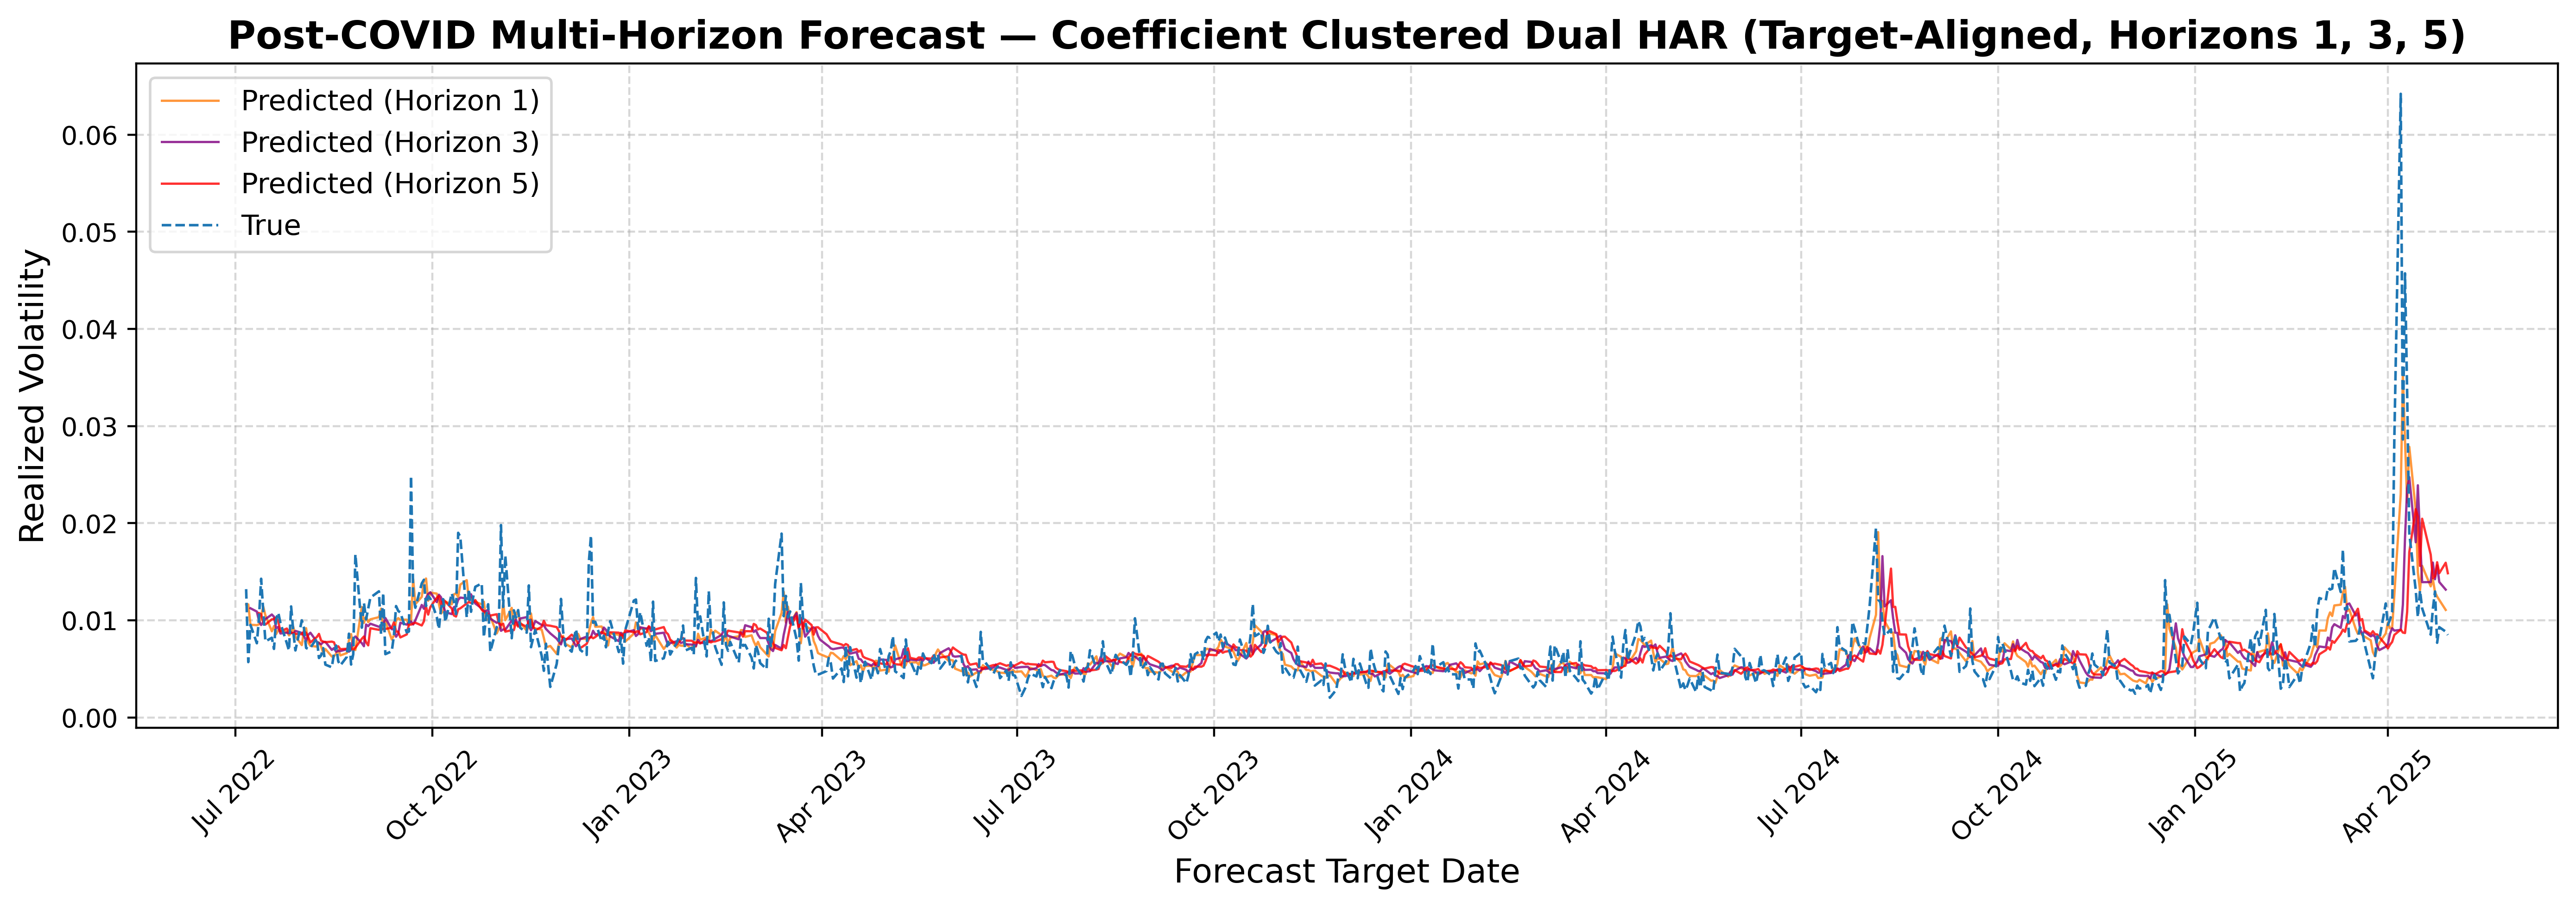

In [57]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
from collections import defaultdict
import numpy as np

predict_days = 5
horizons = [0, 2, 4]  # Horizons 1, 3, 5 (0-indexed)

# Trim arrays so they can be reshaped cleanly into blocks of size predict_days
num_blocks = len(pred_rv) // predict_days
trim_len = num_blocks * predict_days

pred_rv_trim = pred_rv[:trim_len]
true_rv_trim = true_rv[:trim_len]
pred_idx_trim = pred_idx[:trim_len]

# Get target dates for each prediction
prediction_dates = X.iloc[pred_idx_trim].index[:trim_len]

# Reshape to blocks: each row is one forecast window of 5 days
pred_rv_blocked = pred_rv_trim.reshape(num_blocks, predict_days)
true_rv_blocked = true_rv_trim.reshape(num_blocks, predict_days)
dates_blocked = prediction_dates.values.reshape(num_blocks, predict_days)

# Collect horizon data aligned by target date
horizon_data = defaultdict(list)
for i in range(num_blocks):
    for h in horizons:
        horizon_data[h].append({
            'Date': dates_blocked[i, h],
            'Predicted': pred_rv_blocked[i, h],
            'True': true_rv_blocked[i, h]
        })

# Colors for horizons
cluster_colors = {
    0: '#ff7f0e',  # Horizon 1 → orange
    2: 'purple',   # Horizon 3 → purple
    4: 'red',      # Horizon 5 → red
}
true_color = '#1f77b4'  # blue

# Plot
fig, ax = plt.subplots(figsize=(14, 5), dpi=400)

for h in horizons:
    df_h = pd.DataFrame(horizon_data[h]).drop_duplicates(subset='Date').set_index('Date').sort_index()
    ax.plot(
        df_h.index,
        df_h['Predicted'],
        label=f'Predicted (Horizon {h+1})',
        color=cluster_colors.get(h, 'black'),
        linestyle='-',
        linewidth=0.9,
        alpha=0.8
    )

# Plot true values aligned to target date
df_true = pd.DataFrame([
    {'Date': d, 'True': t} for d, t in zip(prediction_dates, true_rv_trim)
]).drop_duplicates(subset='Date').set_index('Date').sort_index()

ax.plot(
    df_true.index,
    df_true['True'],
    label='True',
    color=true_color,
    linestyle='--',
    linewidth=1
)

# Formatting
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.title("Post-COVID Multi-Horizon Forecast — Coefficient Clustered Dual HAR (Target-Aligned, Horizons 1, 3, 5)", fontsize=15, weight='bold')
plt.xlabel("Forecast Target Date", fontsize=13)
plt.ylabel("Realized Volatility", fontsize=13)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11, frameon=True, loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("APost-COVID_multi_horizon_forecast_StandardDualHAR_5day_Coef.pdf", format="pdf", dpi=400, bbox_inches='tight')
plt.show()


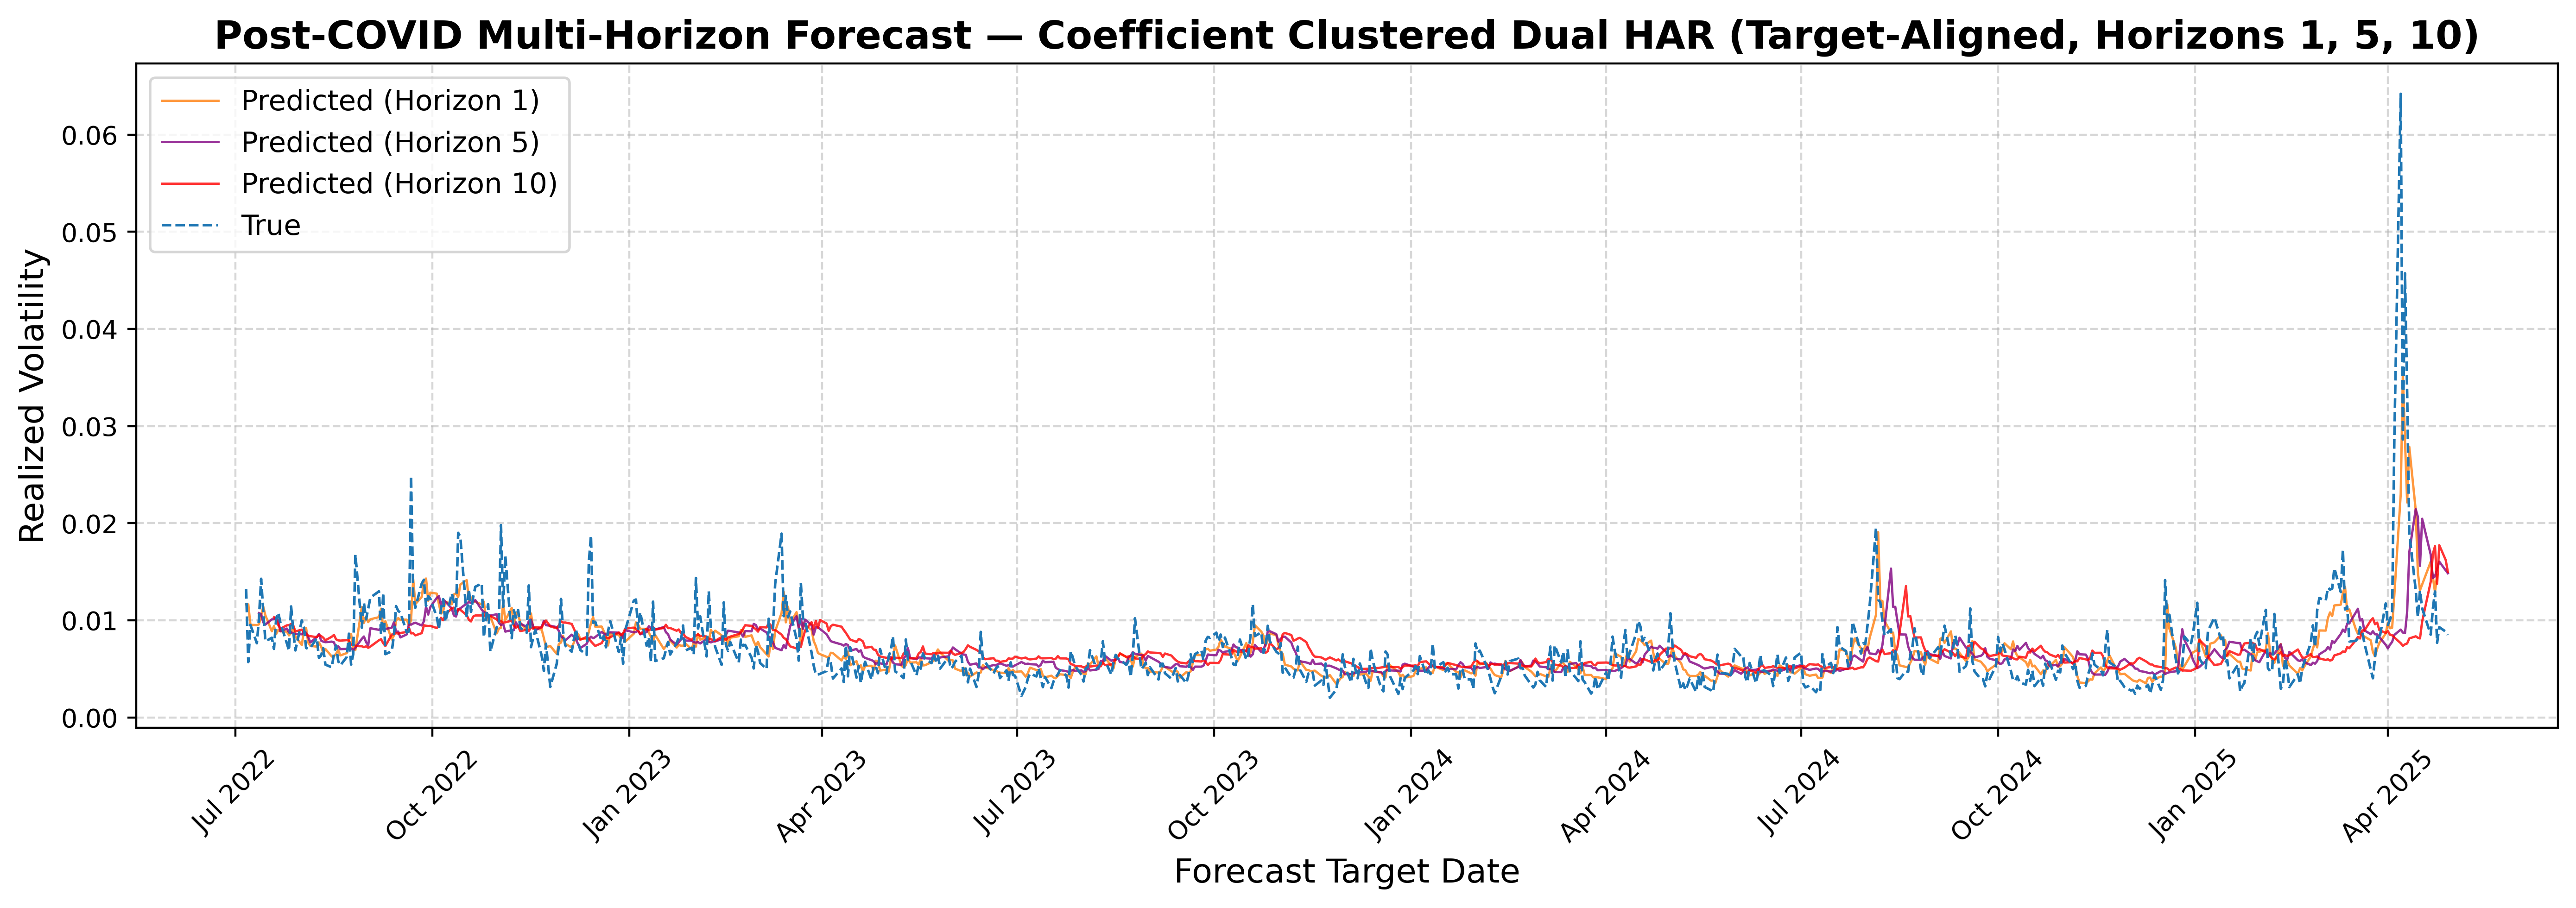

In [69]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
from collections import defaultdict
import numpy as np

# Set horizon parameters
predict_days = 10
horizons = [0, 4, 9]  # Horizon 1, 5, 10

# Reshape into blocks of size `predict_days`
num_blocks = len(pred_rv) // predict_days

# Trim arrays to make clean blocks (just in case)
trim_len = num_blocks * predict_days
pred_rv = pred_rv[:trim_len]
true_rv = true_rv[:trim_len]
pred_idx = pred_idx[:trim_len]
prediction_dates = X.iloc[pred_idx].index[:trim_len]

# Reshape arrays
pred_rv_blocked = pred_rv.reshape(num_blocks, predict_days)
true_rv_blocked = true_rv.reshape(num_blocks, predict_days)
dates_blocked = prediction_dates.values.reshape(num_blocks, predict_days)

# Collect data by target date and horizon
horizon_data = defaultdict(list)

for i in range(num_blocks):
    for h in horizons:
        horizon_data[h].append({
            'Date': dates_blocked[i, h],
            'Predicted': pred_rv_blocked[i, h],
            'True': true_rv_blocked[i, h]
        })

# Color scheme for horizons
cluster_colors = {
    0: '#ff7f0e',  # Horizon 1 → orange
    4: 'purple',   # Horizon 5 → purple
    9: 'red',      # Horizon 10 → red
}
true_color = '#1f77b4'

# Create plot
fig, ax = plt.subplots(figsize=(14, 5), dpi=400)

# Plot predictions
for h in horizons:
    df_h = pd.DataFrame(horizon_data[h]).drop_duplicates(subset='Date').set_index('Date').sort_index()
    ax.plot(
        df_h.index,
        df_h['Predicted'],
        label=f'Predicted (Horizon {h+1})',
        color=cluster_colors.get(h, 'black'),
        linestyle='-',
        linewidth=0.9,
        alpha=0.8
    )

# Plot true values at each date (remove duplicates)
df_true = pd.DataFrame([
    {'Date': d, 'True': t}
    for d, t in zip(prediction_dates, true_rv)
]).drop_duplicates(subset='Date').set_index('Date').sort_index()

ax.plot(
    df_true.index,
    df_true['True'],
    label='True',
    color=true_color,
    linestyle='--',
    linewidth=1
)

# Date formatting
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

# Styling
plt.title("Post-COVID Multi-Horizon Forecast — Coefficient Clustered Dual HAR (Target-Aligned, Horizons 1, 5, 10)", fontsize=15, weight='bold')
plt.xlabel("Forecast Target Date", fontsize=13)
plt.ylabel("Realized Volatility", fontsize=13)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11, frameon=True, loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()

# Save
plt.savefig("APre-COVID_multi_horizon_forecast_StandardDualHAR_10day.pdf", format="pdf", dpi=400, bbox_inches='tight')
plt.show()


In [129]:
X

,VIX,RV_day,RV_week,RV_month,realized_kurt,VIX_week,VIX_month
Date,,,,,,,
2014-06-02,11.58,0.003872,0.002929,0.004039,5.010462,11.548,12.434545
2014-06-03,11.87,0.002720,0.002966,0.003972,3.741934,11.620,12.371818
2014-06-04,12.08,0.002779,0.002938,0.003853,7.626955,11.700,12.334091
2014-06-05,11.68,0.003762,0.003146,0.003825,3.213550,11.722,12.260909
2014-06-06,10.73,0.002433,0.003113,0.003732,5.535330,11.588,12.121364
...,...,...,...,...,...,...,...
2025-04-23,28.45,0.012969,0.011397,0.016977,2.431502,31.026,30.070000
2025-04-24,26.47,0.007693,0.010320,0.017103,2.674487,29.792,30.478636
2025-04-25,24.84,0.009297,0.009932,0.017342,4.142125,28.830,30.828182


In [112]:
print(f"Type of pred_idx: {type(pred_idx)}")
print(f"Sample pred_idx values: {pred_idx[:10]}")

print(f"Type of X.index: {type(X.index)}")
print(f"Sample X.index values: {X.index[:10]}")
print(f"Length of X.index: {len(X.index)}")
print(f"Max pred_idx: {max(pred_idx)}")
print(f"Min pred_idx: {min(pred_idx)}")
print(f"Length of pred_idx: {len(pred_idx)}")


Type of pred_idx: <class 'numpy.ndarray'>
Sample pred_idx values: [463 464 465 466 467 464 465 466 467 468]
Type of X.index: <class 'pandas.core.indexes.base.Index'>
Sample X.index values: Index(['2014-06-02', '2014-06-03', '2014-06-04', '2014-06-05', '2014-06-06',
       '2014-06-09', '2014-06-10', '2014-06-11', '2014-06-12', '2014-06-13'],
      dtype='object', name='Date')
Length of X.index: 2744
Max pred_idx: 1000
Min pred_idx: 463
Length of pred_idx: 2680


In [40]:
import matplotlib.pyplot as plt
import pandas as pd

# Step 1: Get the prediction dates
prediction_dates = y.index[prediction_indices]

# Step 2: Build a DataFrame for easy plotting
df_plot = pd.DataFrame({
    'Date': prediction_dates,
    'True': y_true.ravel(),
    'Predicted': y_pred.ravel()
}).set_index('Date')

# Step 3: Plot
plt.figure(figsize=(14, 5))
plt.plot(df_plot.index, df_plot['True'], label='True', linewidth=1)
plt.plot(df_plot.index, df_plot['Predicted'], label='Predicted', linewidth=1, linestyle='--')
plt.title('True vs Predicted Realized Volatility')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.legend()
plt.tight_layout()
plt.show()


NameError: name 'prediction_indices' is not defined

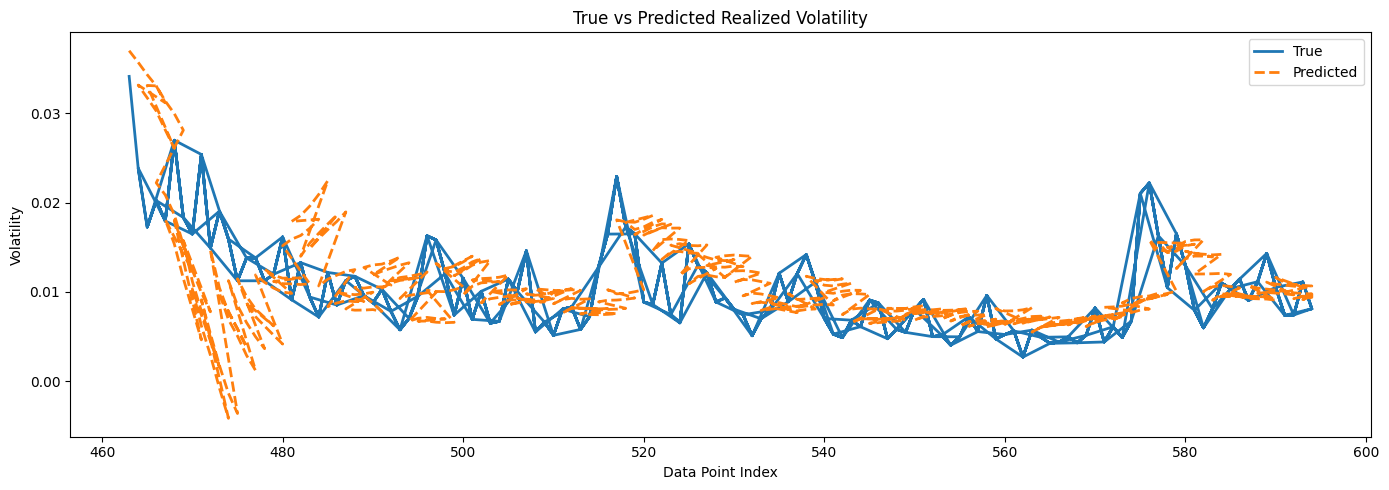

In [76]:
import matplotlib.pyplot as plt
import pandas as pd

# Step 1: Build a DataFrame using just index numbers
df_plot = pd.DataFrame({
    'Index': pred_idx,
    'True': true_rv.ravel(),
    'Predicted': pred_rv.ravel()
}).set_index('Index')

# Step 2: Plot
plt.figure(figsize=(14, 5))
plt.plot(df_plot.index, df_plot['True'], label='True', linewidth=2)
plt.plot(df_plot.index, df_plot['Predicted'], label='Predicted', linewidth=2, linestyle='--')
plt.title('True vs Predicted Realized Volatility')
plt.xlabel('Data Point Index')
plt.ylabel('Volatility')
plt.legend()
plt.tight_layout()
plt.show()


In [120]:
# Convert to correct shape & evaluate
import numpy as np
import joblib
from sklearn.metrics import mean_squared_error


y_true = true_rv
y_pred = pred_rv

# Reshape and inverse transform
#y_true = scaler.inverse_transform(np.array(true_rv).reshape(-1, 1))
#y_pred = scaler.inverse_transform(np.array(pred_rv).reshape(-1, 1))

mse = mean_squared_error(y_true, y_pred)

print(f"Mean Squared Error (MSE): {mse:.8f}")

Mean Squared Error (MSE): 0.00001438


In [103]:
import numpy as np
from sklearn.metrics import mean_absolute_percentage_error

# naive prediction: next day's vol = today's vol
y_pred = y_true[:-1]
y_true_next = y_true[1:]

print("Naive MAPE:", mean_absolute_percentage_error(y_true_next, y_pred))

Naive MAPE: 0.34769176403007085


In [219]:
np.save("standard_har_preds.npy", y_pred)
np.save("y_true.npy", y_true)

In [218]:
import numpy as np

def qlike(y_true, y_pred):
    """
    Canonical QLIKE loss: log(pred) + true/pred - log(true) - 1

    Parameters:
    - y_true: true realized variances (must be > 0)
    - y_pred: predicted variances (must be > 0)

    Returns:
    - qlike_loss: scalar average QLIKE loss
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    eps = 1e-8
    y_true = np.clip(y_true, eps, None)
    y_pred = np.clip(y_pred, eps, None)

    return np.mean(np.log(y_pred) + y_true / y_pred - np.log(y_true) - 1)
qlike(y_true, y_pred)

0.09399007969436755